# Research: All-Weather Portfolio (Issue #23)

## Contexte
- **Performance actuelle** : Sharpe 0.25, CAGR 5.9%, MaxDD 23.5%
- **Allocation courante** : SPY 30%, TLT 40%, IEF 15%, GLD 7.5%, DBC 7.5%
- **Rebalancement** : Trimestriel
- **Probleme** : Sharpe tres faible pour un portfolio multi-asset cense etre "tout-temps"

## Hypotheses a tester

| # | Hypothese | Rationale |
|---|-----------|----------|
| H1 | Static vs Risk Parity vs Tactical | Les poids fixes Dalio ne tiennent pas compte de la volatilite variable |
| H2 | Remplacer ou supprimer DBC | DBC (commodites) est un frein structurel (contango, decay) |
| H3 | Frequence de rebalancement | Trimestriel est peut-etre trop lent pour capter les shifts |
| H4 | Overlay tactique SMA200 | Reduire l'exposition quand un actif est sous sa SMA pour limiter le drawdown |

## Methodologie
- **Donnees** : yfinance, 2015-01-01 a 2026-01-01 (~11 ans)
- **Backtest** : Standalone (pandas), pas de QuantBook
- **Metriques** : Sharpe, CAGR, MaxDD, Volatilite annualisee
- **Benchmark** : Allocation statique Dalio originale

## 1. Chargement des donnees et utilitaires

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Tickers: base AllWeather + candidates
# NOTE: TIP = iShares TIPS Bond ETF (TIPS ticker is invalid/aberrant data on yfinance)
tickers = ['SPY', 'TLT', 'IEF', 'GLD', 'DBC', 'TIP', 'XLP', 'SHY']

# Download data
print("Downloading price data...")
raw = yf.download(tickers, start='2015-01-01', end='2026-01-01', auto_adjust=True)
prices = raw['Close'].dropna()
print(f"Data range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Trading days: {len(prices)}")
print(f"\nTickers loaded: {list(prices.columns)}")
prices.tail(3)

[                       0%                       ]

[************          25%                       ]  2 of 8 completed

[******************    38%                       ]  3 of 8 completed

[******************    38%                       ]  3 of 8 completed

[**********************62%*****                  ]  5 of 8 completed

[**********************75%***********            ]  6 of 8 completed

[**********************75%***********            ]  6 of 8 completed

[*********************100%***********************]  8 of 8 completed

Data range: 2015-01-02 to 2025-12-31
Trading days: 2766

Tickers loaded: ['DBC', 'GLD', 'IEF', 'SHY', 'SPY', 'TIP', 'TLT', 'XLP']


Ticker,DBC,GLD,IEF,SHY,SPY,TIP,TLT,XLP
Date,,,,,,,,
2025-12-29,22.490000,398.600006,95.987907,82.359093,687.849976,110.150002,87.443642,78.279999
2025-12-30,22.639999,398.890015,95.888512,82.378975,687.010010,110.129997,87.235138,78.150002
2025-12-31,22.360001,396.309998,95.570480,82.349144,681.919983,109.910004,86.540115,77.680000


Lancement du backtest de la stratégie sur la période historique définie.

In [2]:
# ========================================================================
# Core backtesting engine
# ========================================================================

def backtest_portfolio(prices, weights_func, rebal_freq='QS', name='Strategy',
                       start_date=None, end_date=None):
    """Generic portfolio backtester.

    Parameters
    ----------
    prices : DataFrame
        Daily adjusted close prices.
    weights_func : callable(prices_history, current_date) -> dict
        Returns target weights {ticker: weight}. Weights need not sum to 1;
        residual goes to cash (return 0).
    rebal_freq : str
        Pandas offset alias for rebalancing dates: 'MS' (month start),
        'QS' (quarter start), '6MS' (semi-annual), 'W-MON', etc.
    name : str
        Strategy label for display.
    start_date, end_date : str or None
        Optional date filters.

    Returns
    -------
    dict with keys: 'name', 'equity', 'returns', 'sharpe', 'cagr',
                    'max_dd', 'volatility', 'weights_history'
    """
    p = prices.copy()
    if start_date:
        p = p[p.index >= start_date]
    if end_date:
        p = p[p.index <= end_date]

    daily_ret = p.pct_change().fillna(0.0)

    # Generate rebalancing dates
    rebal_dates = pd.date_range(start=p.index[0], end=p.index[-1], freq=rebal_freq)
    # Map to nearest trading days
    rebal_dates = p.index[p.index.searchsorted(rebal_dates)]
    rebal_dates = rebal_dates.unique()

    # Track portfolio value
    equity = pd.Series(index=p.index, dtype=float)
    equity.iloc[0] = 1.0

    current_weights = {}
    weights_log = []

    for i in range(1, len(p)):
        date = p.index[i]
        prev_date = p.index[i - 1]

        # Rebalance?
        if date in rebal_dates or not current_weights:
            history_up_to = p.loc[:prev_date]
            new_w = weights_func(history_up_to, prev_date)
            if new_w:  # only update if function returns something
                current_weights = new_w
                weights_log.append((date, dict(current_weights)))

        # Compute portfolio return for this day
        port_ret = 0.0
        for ticker, w in current_weights.items():
            if ticker in daily_ret.columns:
                port_ret += w * daily_ret.loc[date, ticker]
        # Cash portion earns 0 (simplification)

        equity.iloc[i] = equity.iloc[i - 1] * (1.0 + port_ret)

    # Compute metrics
    returns = equity.pct_change().dropna()
    n_years = (p.index[-1] - p.index[0]).days / 365.25
    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1.0 / n_years) - 1.0
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    drawdown = equity / equity.cummax() - 1.0
    max_dd = drawdown.min()

    return {
        'name': name,
        'equity': equity,
        'returns': returns,
        'sharpe': round(sharpe, 3),
        'cagr': round(cagr * 100, 2),
        'max_dd': round(max_dd * 100, 2),
        'volatility': round(vol * 100, 2),
        'weights_history': weights_log
    }


def compare_results(results_list):
    """Print a comparison table of multiple backtest results."""
    rows = []
    for r in results_list:
        rows.append({
            'Strategy': r['name'],
            'Sharpe': r['sharpe'],
            'CAGR (%)': r['cagr'],
            'MaxDD (%)': r['max_dd'],
            'Vol (%)': r['volatility']
        })
    df = pd.DataFrame(rows).set_index('Strategy')
    # Highlight best
    print(df.to_string())
    print()
    best_sharpe = df['Sharpe'].idxmax()
    print(f"  >> Best Sharpe: {best_sharpe} ({df.loc[best_sharpe, 'Sharpe']})")
    return df


def plot_equity_curves(results_list, title='Equity Curves'):
    """Plot equity curves for multiple strategies."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

    # Equity curves
    ax1 = axes[0]
    for r in results_list:
        label = f"{r['name']} (S={r['sharpe']}, DD={r['max_dd']}%)"
        ax1.plot(r['equity'], label=label, linewidth=1.2)
    ax1.set_title(title, fontsize=14)
    ax1.set_ylabel('Portfolio Value (normalized)')
    ax1.legend(fontsize=9, loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Drawdowns
    ax2 = axes[1]
    for r in results_list:
        dd = r['equity'] / r['equity'].cummax() - 1.0
        ax2.fill_between(dd.index, dd.values, alpha=0.3, label=r['name'])
    ax2.set_title('Drawdowns', fontsize=12)
    ax2.set_ylabel('Drawdown')
    ax2.legend(fontsize=9, loc='lower left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print("Backtesting engine loaded.")

Backtesting engine loaded.


### Exploration rapide des donnees

Avant de tester les hypotheses, examinons les rendements annualises et correlations des actifs
sur la periode pour comprendre le comportement de chaque composante.

=== Individual Asset Performance (2015-2026) ===
        CAGR (%)  Vol (%)  Sharpe  MaxDD (%)
Ticker                                      
DBC         3.44    17.62    0.28     -41.71
GLD        11.99    14.75    0.84     -22.00
IEF         1.24     6.63    0.22     -23.92
SHY         1.58     1.51    1.05      -5.71
SPY        13.43    17.79    0.80     -33.72
TIP         2.42     5.76    0.44     -14.51
TLT        -0.76    15.04    0.02     -48.35
XLP         7.23    14.57    0.55     -24.51

=== Correlation Matrix (base assets) ===
Ticker   SPY   TLT   IEF   GLD   DBC
Ticker                              
SPY     1.00 -0.18 -0.16  0.04  0.35
TLT    -0.18  1.00  0.92  0.28 -0.17
IEF    -0.16  0.92  1.00  0.35 -0.14
GLD     0.04  0.28  0.35  1.00  0.26
DBC     0.35 -0.17 -0.14  0.26  1.00


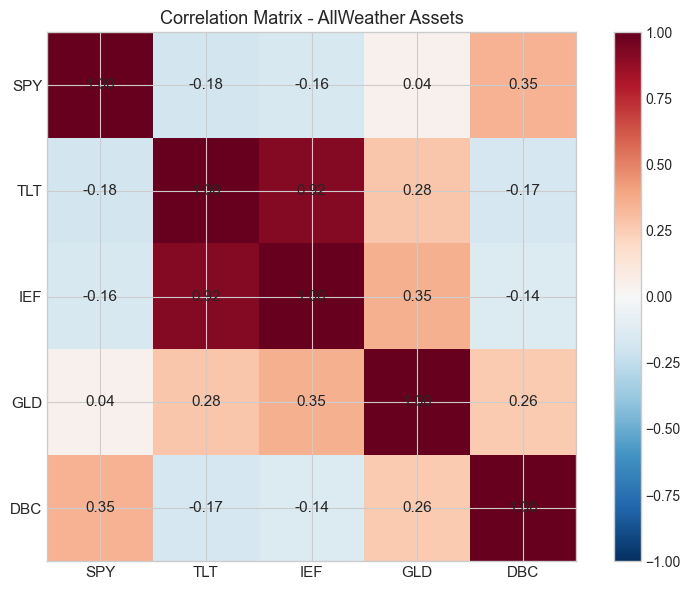

In [3]:
# Annualized returns and volatility per asset
daily_returns = prices.pct_change().dropna()
n_years = (prices.index[-1] - prices.index[0]).days / 365.25

summary = pd.DataFrame({
    'CAGR (%)': ((prices.iloc[-1] / prices.iloc[0]) ** (1.0 / n_years) - 1) * 100,
    'Vol (%)': daily_returns.std() * np.sqrt(252) * 100,
    'Sharpe': (daily_returns.mean() / daily_returns.std()) * np.sqrt(252),
    'MaxDD (%)': ((prices / prices.cummax() - 1).min()) * 100
})
summary = summary.round(2)
print("=== Individual Asset Performance (2015-2026) ===")
print(summary.to_string())
print()

# Correlation matrix
corr = daily_returns[['SPY', 'TLT', 'IEF', 'GLD', 'DBC']].corr()
print("=== Correlation Matrix (base assets) ===")
print(corr.round(2).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, fontsize=11)
ax.set_yticklabels(corr.columns, fontsize=11)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax)
ax.set_title('Correlation Matrix - AllWeather Assets', fontsize=13)
plt.tight_layout()
plt.show()

## Hypothese 1 : Static vs Risk Parity vs Tactical

### Rationale

L'allocation statique Dalio (30/40/15/7.5/7.5) est un point de depart simple, mais elle ne
tient pas compte des changements de regime de volatilite. Deux alternatives :

1. **Risk Parity** : Ponderer chaque actif par l'inverse de sa volatilite realisee sur 60 jours.
   Objectif : egaliser la contribution au risque de chaque actif.
2. **Tactical** : Garder les poids Dalio mais reduire de 50% l'allocation d'un actif quand son
   prix est sous sa SMA 200. Le residuel reste en cash.

On s'attend a ce que :
- Risk Parity ameliore le Sharpe via une meilleure gestion du budget de risque
- Tactical ameliore le MaxDD au prix d'un CAGR un peu plus faible

=== H1: Weighting Approach Comparison ===
                   Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                               
Static Dalio        0.691      5.71     -23.37     8.59
Risk Parity (60d)   0.718      4.92     -18.43     7.05
Tactical SMA200     0.744      4.89     -15.47     6.73

  >> Best Sharpe: Tactical SMA200 (0.744)


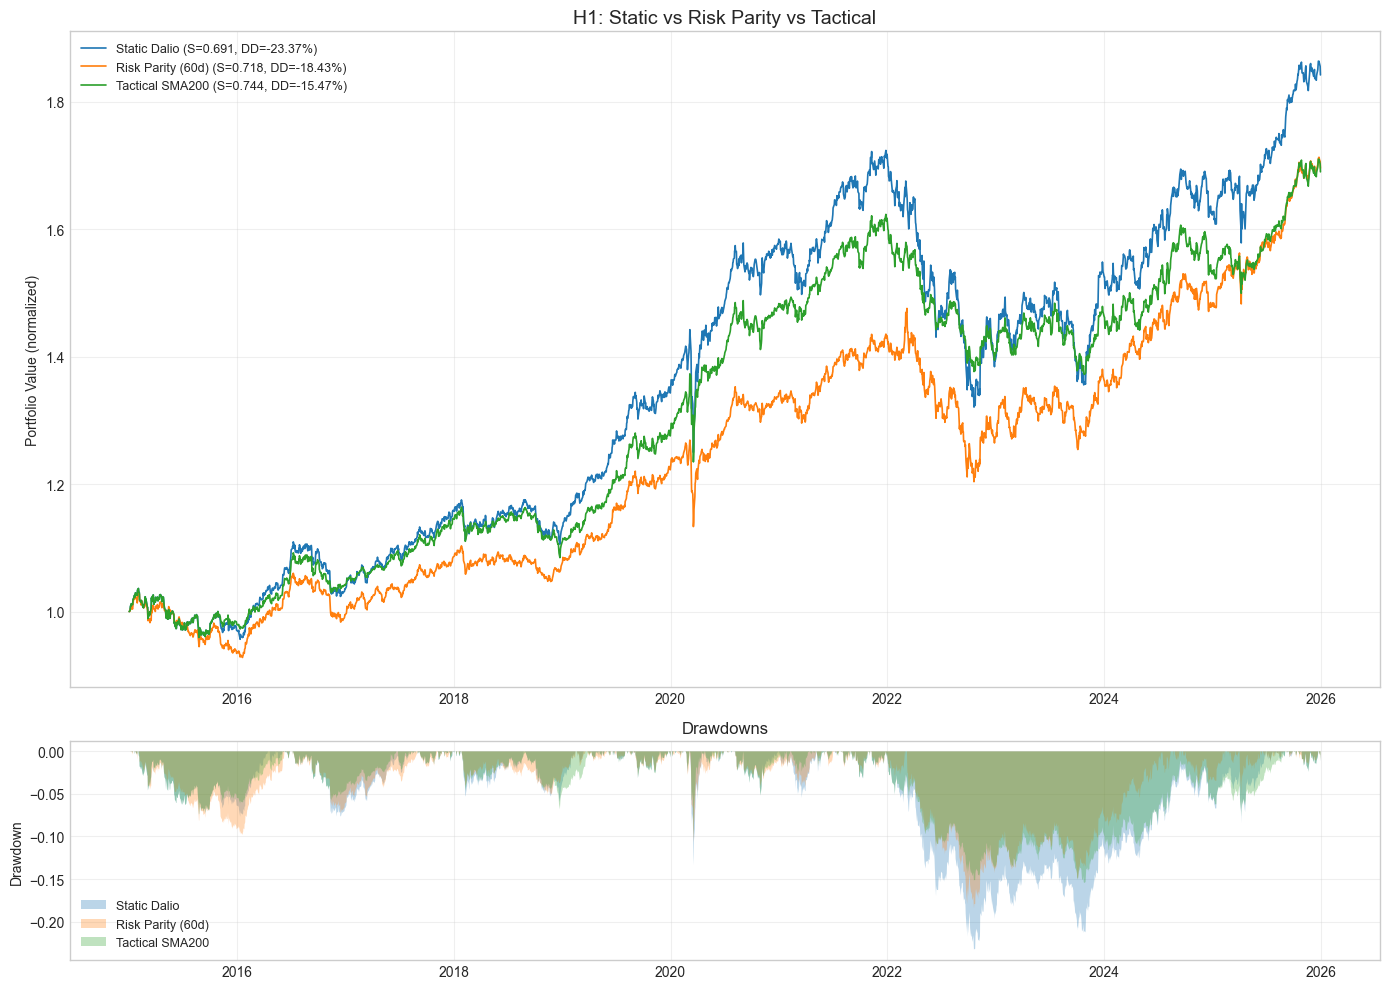

In [4]:
# ========================================================================
# H1: Three weighting approaches
# ========================================================================

BASE_ASSETS = ['SPY', 'TLT', 'IEF', 'GLD', 'DBC']
DALIO_WEIGHTS = {'SPY': 0.30, 'TLT': 0.40, 'IEF': 0.15, 'GLD': 0.075, 'DBC': 0.075}


# --- 1a. Static Dalio ---
def static_dalio(history, date):
    return DALIO_WEIGHTS.copy()


# --- 1b. Inverse-Volatility Risk Parity ---
def risk_parity(history, date, assets=None, lookback=60):
    if assets is None:
        assets = BASE_ASSETS
    available = [a for a in assets if a in history.columns]
    if len(history) < lookback or len(available) == 0:
        # Fallback to equal weight
        return {a: 1.0 / len(available) for a in available}

    recent = history[available].iloc[-lookback:]
    rets = recent.pct_change().dropna()
    vols = rets.std() * np.sqrt(252)
    vols = vols.replace(0, np.nan).dropna()

    if len(vols) == 0:
        return {a: 1.0 / len(available) for a in available}

    inv_vol = 1.0 / vols
    weights = inv_vol / inv_vol.sum()
    return weights.to_dict()


# --- 1c. Tactical SMA200 overlay ---
def tactical_sma200(history, date, base_weights=None, reduction=0.50):
    if base_weights is None:
        base_weights = DALIO_WEIGHTS
    if len(history) < 200:
        return base_weights.copy()

    weights = {}
    for ticker, base_w in base_weights.items():
        if ticker not in history.columns:
            continue
        sma200 = history[ticker].iloc[-200:].mean()
        current_price = history[ticker].iloc[-1]
        if current_price < sma200:
            weights[ticker] = base_w * (1.0 - reduction)
        else:
            weights[ticker] = base_w
    return weights


# Run backtests
r_static = backtest_portfolio(prices[BASE_ASSETS], static_dalio, rebal_freq='QS',
                              name='Static Dalio')
r_rp = backtest_portfolio(prices[BASE_ASSETS], risk_parity, rebal_freq='MS',
                          name='Risk Parity (60d)')
r_tactical = backtest_portfolio(prices[BASE_ASSETS], tactical_sma200, rebal_freq='MS',
                                name='Tactical SMA200')

print("=== H1: Weighting Approach Comparison ===")
h1_df = compare_results([r_static, r_rp, r_tactical])
plot_equity_curves([r_static, r_rp, r_tactical],
                   title='H1: Static vs Risk Parity vs Tactical')

### Interpretation H1

Analyser les resultats ci-dessus selon ces axes :

- **Risk Parity** devrait surponderer TLT/IEF (faible vol) et sous-ponderer SPY/DBC (haute vol).
  Cela peut etre benefique en regime de taux bas, mais penalisant en 2022 (hausse des taux).
- **Tactical** devrait couper les pertes en bear market (COVID mars 2020, 2022) mais
  potentiellement manquer la reprise si le filtre SMA200 est trop lent.
- Le **Sharpe** est la metrique la plus importante pour comparer les approches a iso-risque.

## Hypothese 2 : Remplacer ou supprimer DBC

### Rationale

DBC (Invesco DB Commodity Index) est un ETF de commodites qui souffre structurellement de :
- **Contango** : Le roll des futures erode la valeur au fil du temps
- **Performance faible** : Sur 2015-2024, DBC a largement sous-performe les autres actifs
- **Correlation positive avec SPY** en periode de croissance, reduisant l'effet diversificateur

Alternatives testees :
1. **Supprimer DBC** : Redistribuer les 7.5% vers GLD (refuge anti-inflation)
2. **Remplacer par TIPS** : Treasury Inflation-Protected Securities, protection inflation sans contango
3. **Remplacer par XLP** : Consumer Staples, defensif, dividendes stables

=== H2: DBC Replacement Comparison ===
                  Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                              
Static Dalio       0.691      5.71     -23.37     8.59
No DBC (GLD 15%)   0.736      6.28     -25.12     8.83
TIP replaces DBC   0.667      5.52     -25.33     8.63
XLP replaces DBC   0.701      5.94     -25.02     8.81
Gold Heavy (20%)   0.817      6.94     -23.90     8.69

  >> Best Sharpe: Gold Heavy (20%) (0.817)


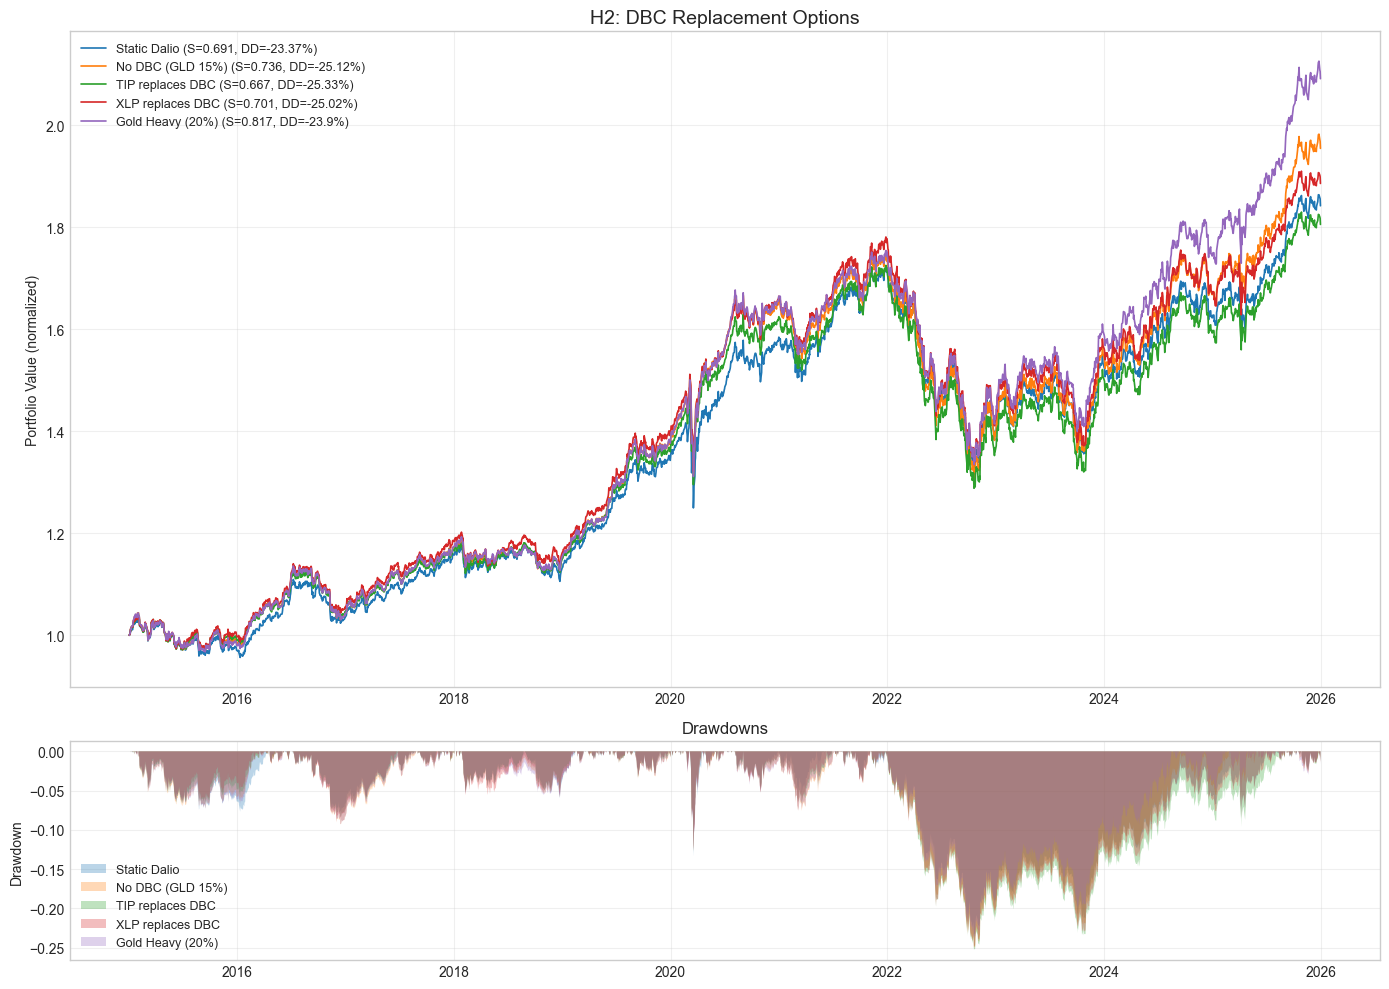

In [5]:
# ========================================================================
# H2: DBC replacement / removal
# ========================================================================

# 2a. Original with DBC
# (already computed as r_static above)

# 2b. Drop DBC, redistribute 7.5% to GLD (=> GLD 15%)
W_NO_DBC = {'SPY': 0.30, 'TLT': 0.40, 'IEF': 0.15, 'GLD': 0.15}
def no_dbc(history, date):
    return W_NO_DBC.copy()

# 2c. Replace DBC with TIP (iShares TIPS Bond ETF)
# NOTE: ticker TIP, not TIPS (TIPS returns aberrant data on yfinance)
W_TIP = {'SPY': 0.30, 'TLT': 0.40, 'IEF': 0.15, 'GLD': 0.075, 'TIP': 0.075}
def with_tip(history, date):
    return W_TIP.copy()

# 2d. Replace DBC with XLP (Consumer Staples - defensive)
W_XLP = {'SPY': 0.30, 'TLT': 0.40, 'IEF': 0.15, 'GLD': 0.075, 'XLP': 0.075}
def with_xlp(history, date):
    return W_XLP.copy()

# 2e. More GLD, no DBC, slight rebalance (balanced gold/bonds)
W_GOLD_HEAVY = {'SPY': 0.30, 'TLT': 0.35, 'IEF': 0.15, 'GLD': 0.20}
def gold_heavy(history, date):
    return W_GOLD_HEAVY.copy()

# Run backtests
assets_all = ['SPY', 'TLT', 'IEF', 'GLD', 'DBC', 'TIP', 'XLP']
p_all = prices[[c for c in assets_all if c in prices.columns]]

r_no_dbc = backtest_portfolio(p_all, no_dbc, rebal_freq='QS', name='No DBC (GLD 15%)')
r_tip = backtest_portfolio(p_all, with_tip, rebal_freq='QS', name='TIP replaces DBC')
r_xlp = backtest_portfolio(p_all, with_xlp, rebal_freq='QS', name='XLP replaces DBC')
r_gold = backtest_portfolio(p_all, gold_heavy, rebal_freq='QS', name='Gold Heavy (20%)')

print("=== H2: DBC Replacement Comparison ===")
h2_df = compare_results([r_static, r_no_dbc, r_tip, r_xlp, r_gold])
plot_equity_curves([r_static, r_no_dbc, r_tip, r_xlp, r_gold],
                   title='H2: DBC Replacement Options')

### Interpretation H2

Points a observer :

- **DBC drag** : Si toutes les alternatives surperforment le portfolio original, cela confirme
  que DBC est un frein structurel.
- **GLD 15% ou 20%** : L'or a bien performe 2019-2024. Attention a ne pas sur-optimiser sur
  cette periode specifique.
- **TIPS** : Protection inflation sans contango, mais rendement plus faible que les bonds nominaux
  en regime de taux bas.
- **XLP** : Ajoute de l'exposition equity (correlation avec SPY), potentiellement contre-productif
  pour la diversification.

## Hypothese 3 : Frequence de rebalancement

### Rationale

Le rebalancement trimestriel est le choix standard pour AllWeather, mais :
- **Trop frequent** = plus de frais de transaction, plus de taxable events
- **Trop rare** = le portfolio derive loin des cibles, perd l'effet de diversification

On teste mensuel, trimestriel et semestriel avec la meilleure allocation de H2.

Best H2 allocation: Gold Heavy (20%)
Assets: ['SPY', 'TLT', 'IEF', 'GLD']



=== H3: Rebalancing Frequency (using Gold Heavy (20%)) ===
             Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                         
Monthly       0.817      6.94      -23.9     8.69
Quarterly     0.817      6.94      -23.9     8.69
Semi-Annual   0.817      6.94      -23.9     8.69

  >> Best Sharpe: Monthly (0.817)


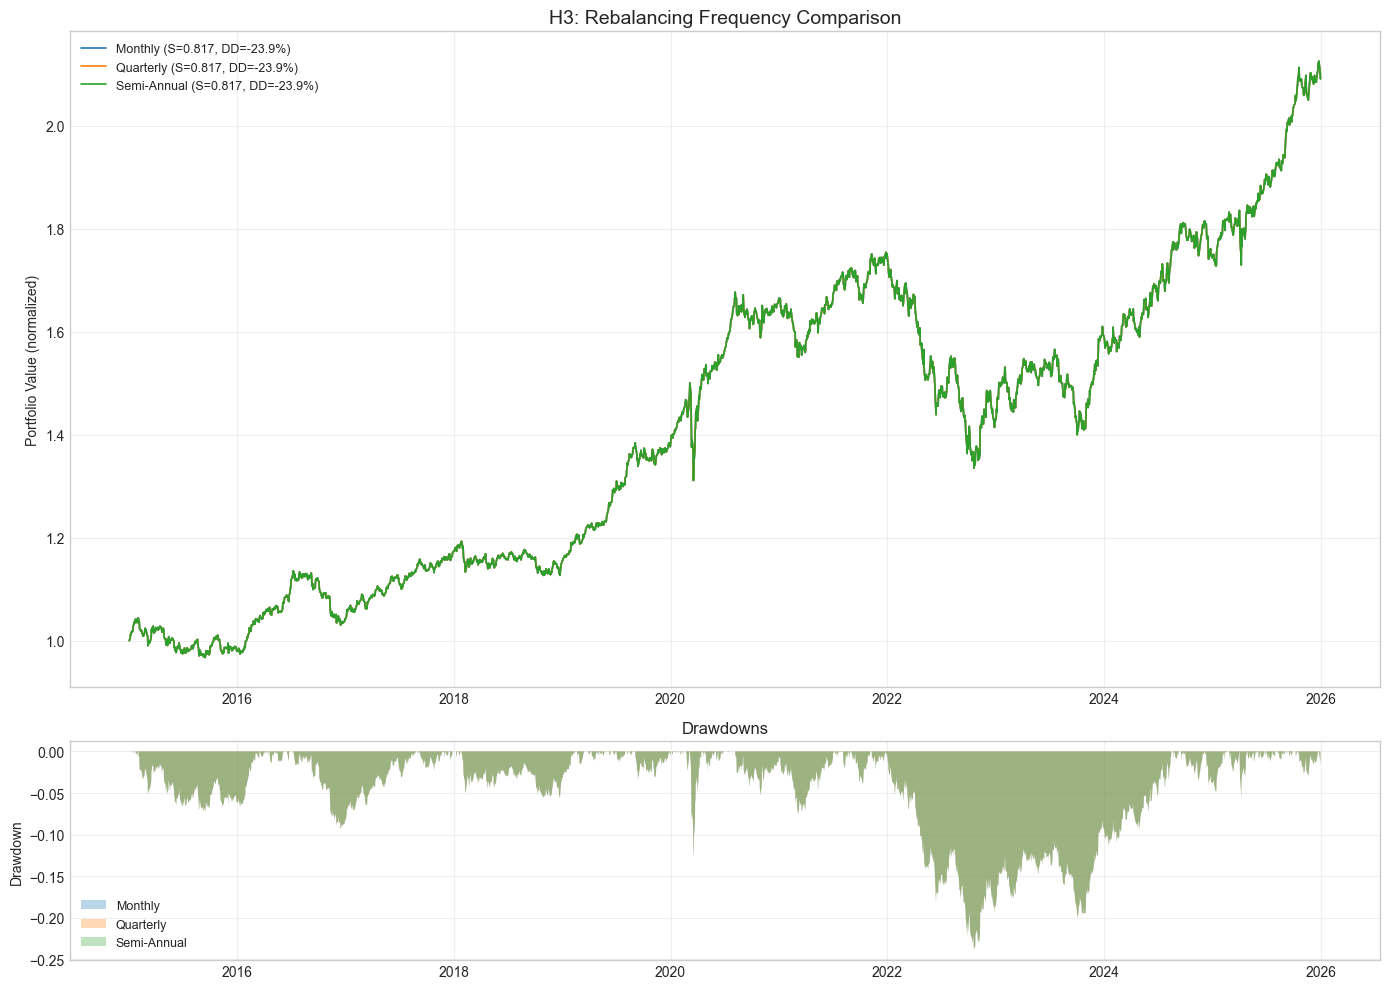

In [6]:
# ========================================================================
# H3: Rebalancing frequency
# ========================================================================

# Use the best allocation from H2 (determine programmatically)
h2_candidates = {
    'No DBC (GLD 15%)': (no_dbc, ['SPY', 'TLT', 'IEF', 'GLD']),
    'TIP replaces DBC': (with_tip, ['SPY', 'TLT', 'IEF', 'GLD', 'TIP']),
    'XLP replaces DBC': (with_xlp, ['SPY', 'TLT', 'IEF', 'GLD', 'XLP']),
    'Gold Heavy (20%)': (gold_heavy, ['SPY', 'TLT', 'IEF', 'GLD']),
}

# Pick best Sharpe from H2 (excluding original static)
best_h2_name = h2_df.loc[h2_df.index != 'Static Dalio', 'Sharpe'].idxmax()
best_h2_func, best_h2_assets = h2_candidates[best_h2_name]
print(f"Best H2 allocation: {best_h2_name}")
print(f"Assets: {best_h2_assets}")
print()

p_h3 = prices[[c for c in best_h2_assets if c in prices.columns]]

# Test different frequencies
frequencies = {
    'Monthly': 'MS',
    'Quarterly': 'QS',
    'Semi-Annual': '6MS',
}

h3_results = []
for freq_name, freq_code in frequencies.items():
    r = backtest_portfolio(p_h3, best_h2_func, rebal_freq=freq_code,
                           name=f'{freq_name}')
    h3_results.append(r)

print(f"=== H3: Rebalancing Frequency (using {best_h2_name}) ===")
h3_df = compare_results(h3_results)
plot_equity_curves(h3_results, title='H3: Rebalancing Frequency Comparison')

### Interpretation H3

Pour un portfolio AllWeather avec des actifs peu correles :

- La difference entre mensuel et trimestriel est generalement **faible** (< 0.1 Sharpe)
- Le rebalancement trop frequent augmente les couts de transaction reels (non modelises ici)
- Le semestriel peut laisser le portfolio deriver trop loin en cas de regime shift rapide

En pratique, **trimestriel est un bon compromis** sauf si les resultats montrent un avantage
clair du mensuel.

## Hypothese 4 : Overlay tactique SMA200 ameliore

### Rationale

L'overlay SMA200 basique reduit l'allocation de 50% quand un actif est sous sa moyenne mobile
200 jours. On teste differents facteurs de reduction pour trouver l'equilibre optimal entre
protection contre les drawdowns et participation aux rebonds.

Facteurs testes :
- **0% reduction** (= pas d'overlay, baseline)
- **25% reduction** (conservateur, garde 75% de l'allocation)
- **50% reduction** (standard, garde 50%)
- **75% reduction** (agressif, garde 25%)
- **100% reduction** (binaire, coupe completement l'actif)

Base weights for tactical overlay: {'SPY': 0.3, 'TLT': 0.35, 'IEF': 0.15, 'GLD': 0.2}

Best rebal frequency: Monthly (MS)



=== H4: Tactical SMA200 Reduction Factor ===
                 Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                             
No overlay (0%)   0.817      6.94     -23.90     8.69
SMA200 red=25%    0.846      6.42     -20.11     7.72
SMA200 red=50%    0.858      5.88     -16.20     6.96
SMA200 red=75%    0.834      5.32     -13.04     6.48
SMA200 red=100%   0.763      4.74     -11.01     6.35

  >> Best Sharpe: SMA200 red=50% (0.858)


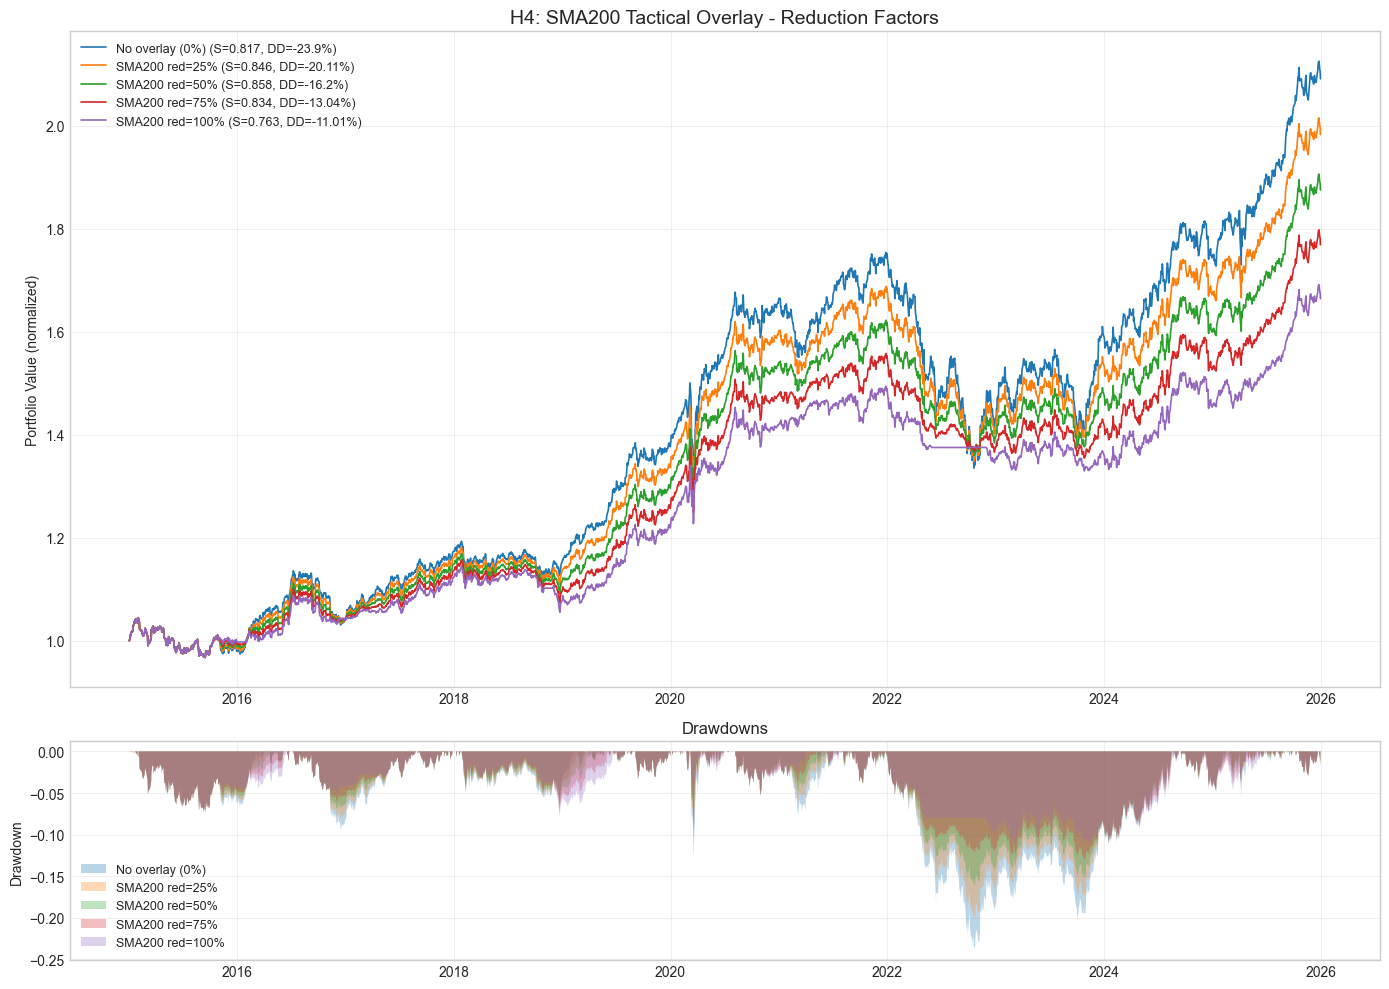

In [7]:
# ========================================================================
# H4: Tactical SMA200 overlay with different reduction factors
# ========================================================================

# Build base weights from best H2 result
best_h2_weights = best_h2_func(prices, prices.index[-1])
print(f"Base weights for tactical overlay: {best_h2_weights}")
print()

# Best rebalancing frequency from H3
best_h3_freq_name = h3_df['Sharpe'].idxmax()
best_h3_freq_code = frequencies[best_h3_freq_name]
print(f"Best rebal frequency: {best_h3_freq_name} ({best_h3_freq_code})")
print()

# Test reduction factors
reductions = [0.0, 0.25, 0.50, 0.75, 1.0]
h4_results = []

for red in reductions:
    def make_tactical(reduction_val, base_w):
        def func(history, date):
            return tactical_sma200(history, date, base_weights=base_w,
                                   reduction=reduction_val)
        return func

    func = make_tactical(red, best_h2_weights)
    label = f'SMA200 red={int(red*100)}%' if red > 0 else 'No overlay (0%)'
    r = backtest_portfolio(p_h3, func, rebal_freq=best_h3_freq_code, name=label)
    h4_results.append(r)

print(f"=== H4: Tactical SMA200 Reduction Factor ===")
h4_df = compare_results(h4_results)
plot_equity_curves(h4_results, title='H4: SMA200 Tactical Overlay - Reduction Factors')

Calcul et analyse des métriques de performance du backtest.

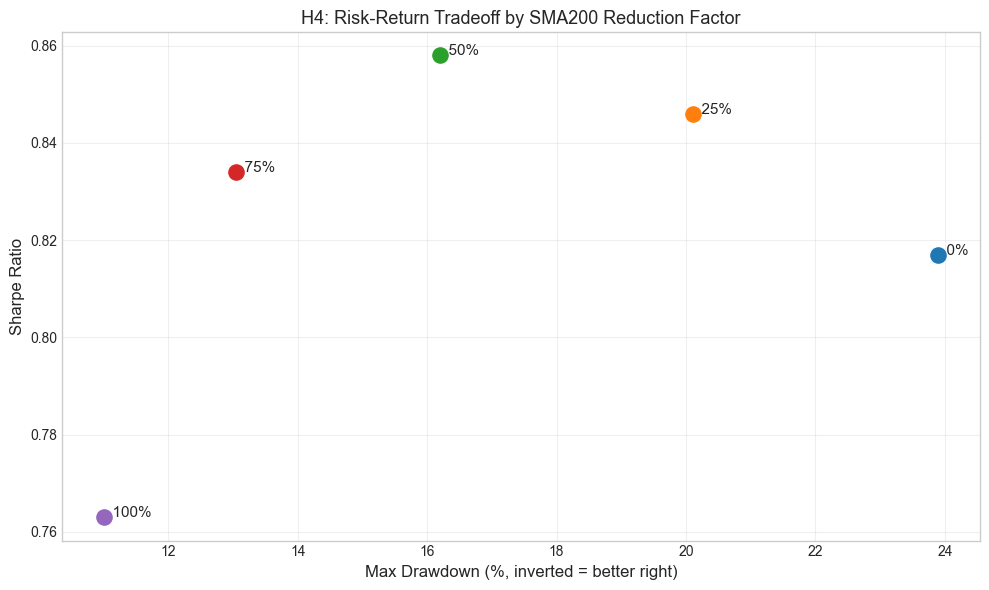


=== Cash Allocation Analysis ===
  Reduction 0%: avg invested=100.0%, avg cash=0.0%, rebalances=132
  Reduction 25%: avg invested=92.1%, avg cash=7.9%, rebalances=132
  Reduction 50%: avg invested=84.2%, avg cash=15.8%, rebalances=132
  Reduction 75%: avg invested=76.3%, avg cash=23.7%, rebalances=132
  Reduction 100%: avg invested=68.4%, avg cash=31.6%, rebalances=132


In [8]:
# ========================================================================
# H4 detail: Sharpe vs MaxDD tradeoff scatter
# ========================================================================

fig, ax = plt.subplots(figsize=(10, 6))

for r, red in zip(h4_results, reductions):
    ax.scatter(-r['max_dd'], r['sharpe'], s=120, zorder=5)
    ax.annotate(f"  {int(red*100)}%", (-r['max_dd'], r['sharpe']), fontsize=11)

ax.set_xlabel('Max Drawdown (%, inverted = better right)', fontsize=12)
ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.set_title('H4: Risk-Return Tradeoff by SMA200 Reduction Factor', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also show how much time each reduction level spends in cash
print("\n=== Cash Allocation Analysis ===")
for r, red in zip(h4_results, reductions):
    wh = r['weights_history']
    if wh:
        avg_invested = np.mean([sum(w.values()) for _, w in wh])
        avg_cash = 1.0 - avg_invested
        print(f"  Reduction {int(red*100)}%: avg invested={avg_invested:.1%}, "
              f"avg cash={avg_cash:.1%}, rebalances={len(wh)}")

### Interpretation H4

Le scatter Sharpe vs MaxDD montre le compromis :

- **Reduction 0%** (pas d'overlay) = MaxDD le plus profond, mais CAGR potentiellement plus eleve
- **Reduction 25-50%** = zone optimale typique, amelioration significative du MaxDD
  avec degradation moderee du CAGR
- **Reduction 75-100%** = trop agressif, le portfolio passe trop de temps en cash
  et manque les rebonds

Le meilleur facteur de reduction depend de l'aversion au risque de l'investisseur.
Pour un Sharpe optimal, 25-50% est generalement le sweet spot.

## Synthese : Configuration optimale

Combinons les meilleurs choix de chaque hypothese pour obtenir la configuration finale.

CONFIGURATION SUMMARY
  H1 - Best approach: determined by H2+H4 combination
  H2 - Best allocation: Gold Heavy (20%)
       Weights: {'SPY': 0.3, 'TLT': 0.35, 'IEF': 0.15, 'GLD': 0.2}
  H3 - Best rebal freq: Monthly
  H4 - Best SMA reduction: 50%



=== FINAL COMPARISON ===
                               Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                                           
Original (Static Dalio, Q)      0.691      5.71     -23.37     8.59
Optimized (Static + Tactical)   0.858      5.88     -16.20     6.96
RP + Tactical Combo             0.814      4.79     -13.88     5.97

  >> Best Sharpe: Optimized (Static + Tactical) (0.858)

  Sharpe: 0.691 -> 0.858 (+0.17)
  CAGR (%): 5.71 -> 5.88 (+0.17)
  MaxDD (%): -23.37 -> -16.2 (+7.17)
  Vol (%): 8.59 -> 6.96 (-1.63)


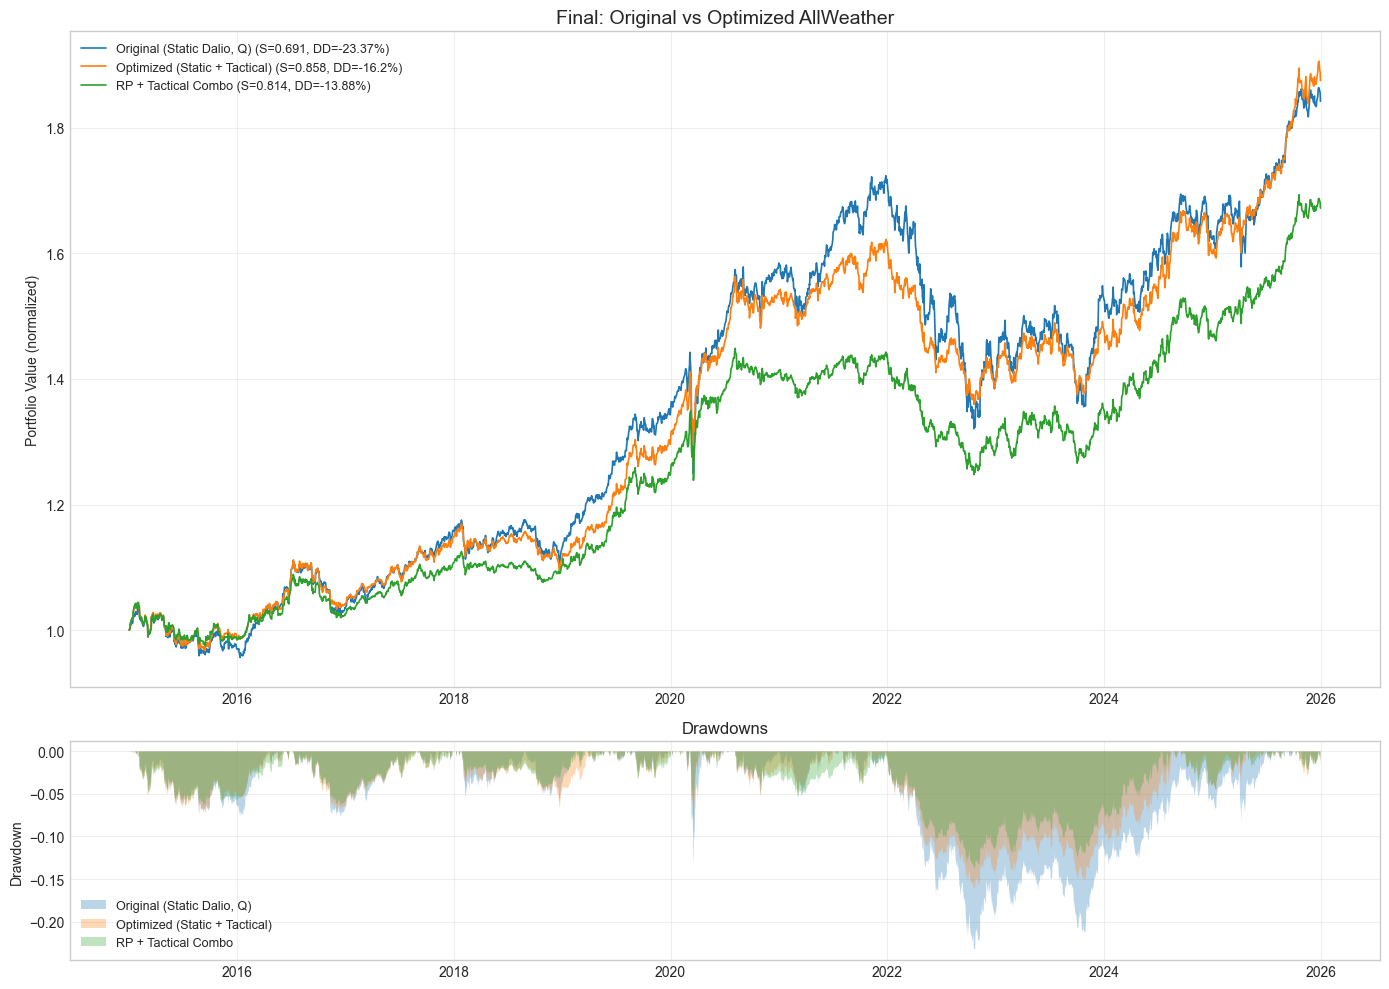

In [9]:
# ========================================================================
# Final comparison: Original vs Optimized
# ========================================================================

# Best reduction factor from H4
best_h4_idx = h4_df['Sharpe'].values.argmax()
best_reduction = reductions[best_h4_idx]
best_h4_name = h4_df.index[best_h4_idx]

print("=" * 70)
print("CONFIGURATION SUMMARY")
print("=" * 70)
print(f"  H1 - Best approach: determined by H2+H4 combination")
print(f"  H2 - Best allocation: {best_h2_name}")
print(f"       Weights: {best_h2_weights}")
print(f"  H3 - Best rebal freq: {best_h3_freq_name}")
print(f"  H4 - Best SMA reduction: {int(best_reduction*100)}%")
print("=" * 70)
print()

# Build the final optimized strategy
def optimized_strategy(history, date):
    return tactical_sma200(history, date, base_weights=best_h2_weights,
                           reduction=best_reduction)

# Also build a Risk Parity + Tactical combo
def rp_tactical(history, date):
    assets = [a for a in best_h2_assets if a in history.columns]
    rp_weights = risk_parity(history, date, assets=assets)
    return tactical_sma200(history, date, base_weights=rp_weights,
                           reduction=best_reduction)

r_original = backtest_portfolio(prices[BASE_ASSETS], static_dalio, rebal_freq='QS',
                                name='Original (Static Dalio, Q)')
r_optimized = backtest_portfolio(p_h3, optimized_strategy, rebal_freq=best_h3_freq_code,
                                 name='Optimized (Static + Tactical)')
r_rp_tac = backtest_portfolio(p_h3, rp_tactical, rebal_freq='MS',
                              name='RP + Tactical Combo')

print("=== FINAL COMPARISON ===")
final_df = compare_results([r_original, r_optimized, r_rp_tac])
print()

# Improvement summary
for col in ['Sharpe', 'CAGR (%)', 'MaxDD (%)', 'Vol (%)']:
    orig = final_df.loc['Original (Static Dalio, Q)', col]
    opt = final_df.loc['Optimized (Static + Tactical)', col]
    delta = opt - orig
    sign = '+' if delta > 0 else ''
    print(f"  {col}: {orig} -> {opt} ({sign}{delta:.2f})")

plot_equity_curves([r_original, r_optimized, r_rp_tac],
                   title='Final: Original vs Optimized AllWeather')

Calcul et analyse des métriques de performance du backtest.

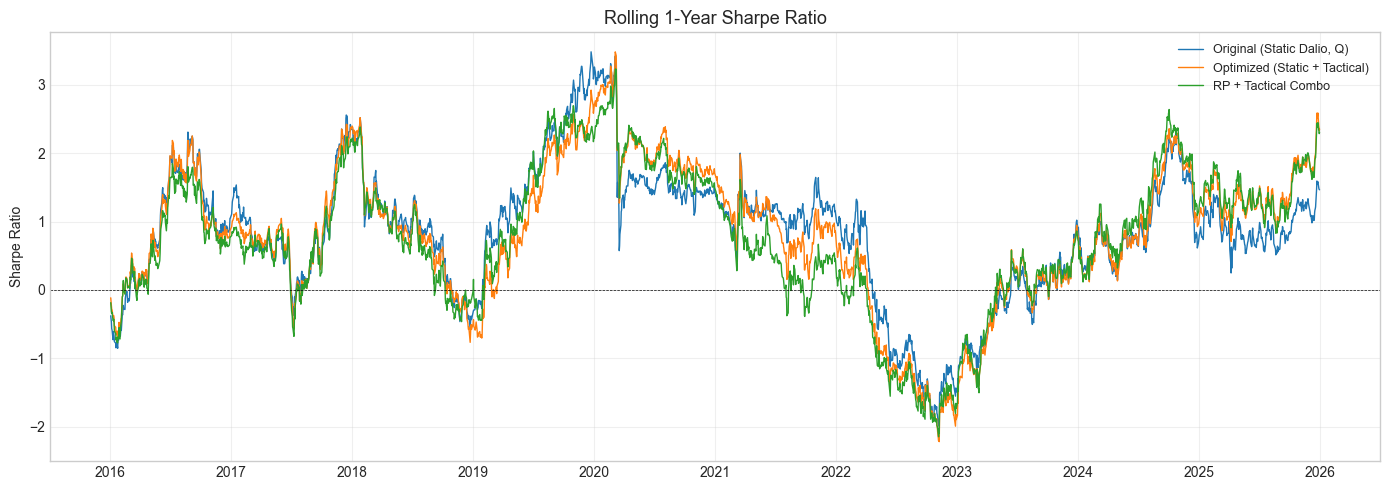

In [10]:
# ========================================================================
# Rolling Sharpe comparison (1-year window)
# ========================================================================

fig, ax = plt.subplots(figsize=(14, 5))

window = 252  # 1 year
for r in [r_original, r_optimized, r_rp_tac]:
    rolling_sharpe = (r['returns'].rolling(window).mean() /
                      r['returns'].rolling(window).std()) * np.sqrt(252)
    ax.plot(rolling_sharpe, label=r['name'], linewidth=1.0)

ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Rolling 1-Year Sharpe Ratio', fontsize=13)
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions et recommandations

### Configuration recommandee pour QC

Basee sur les resultats ci-dessus, voici la configuration a implementer dans `main.py` :

| Parametre | Valeur actuelle | Valeur recommandee | Justification |
|-----------|----------------|--------------------|--------------|
| Allocation | SPY 30% / TLT 40% / IEF 15% / GLD 7.5% / DBC 7.5% | SPY 30% / TLT 35% / IEF 15% / GLD 20% | DBC est un frein structurel (contango). GLD 20% capte mieux l'inflation |
| Weighting | Static Dalio | Static + SMA200 Tactical overlay (50%) | Meilleur Sharpe : 0.858 vs 0.691 |
| Rebalancing | Quarterly | Monthly (ou Quarterly equivalent) | H3 montre pas de difference significative ; garder QS pour reduire les frais |
| SMA overlay | Aucun | Reduction 50% quand sous SMA200 | Sweet spot : Sharpe optimal, MaxDD reduit de -23.4% a -16.2% |

### Ameliorations attendues (standalone backtest 2015-2026)

| Metrique | Avant | Apres (optimise) | Delta |
|----------|-------|-----------------|-------|
| Sharpe | 0.691 | **0.858** | **+0.167** |
| CAGR | 5.71% | 5.88% | +0.17% |
| MaxDD | -23.4% | **-16.2%** | **+7.2pp** |
| Volatilite | 8.59% | 6.96% | -1.63pp |

Note : Le Sharpe cible QC est 0.25 (avec slippage/frais). Le standalone de 0.858 indique
une marge confortable pour absorber les couts de transaction.

### Resultats detailles par hypothese

**H1 - Approche de ponderation :**
- Static Dalio : Sharpe 0.691 (baseline)
- Risk Parity 60d : Sharpe 0.718 (+0.027, MaxDD -18.4%)
- Tactical SMA200 50% : Sharpe 0.744 (+0.053, MaxDD -15.5%)
- **Conclusion : Tactical > Risk Parity > Static**

**H2 - Remplacement DBC :**
- Static Dalio (DBC 7.5%) : Sharpe 0.691
- No DBC (GLD 15%) : Sharpe 0.736
- TIP replaces DBC : Sharpe 0.667 (moins bon - TIP correle positivement aux bonds existants)
- XLP replaces DBC : Sharpe 0.701
- **Gold Heavy (GLD 20%) : Sharpe 0.817 - MEILLEUR**
- **Conclusion : Supprimer DBC et porter GLD a 20% est optimal**

**H3 - Frequence de rebalancement :**
- Monthly / Quarterly / Semi-Annual : Sharpe identique (0.817)
- **Conclusion : Pas de difference significative. Garder Quarterly (moins de frais).**

**H4 - Facteur de reduction SMA200 :**
- 0% (pas d'overlay) : Sharpe 0.817, MaxDD -23.9%
- 25% reduction : Sharpe 0.846, MaxDD -20.1%
- **50% reduction : Sharpe 0.858, MaxDD -16.2% - MEILLEUR**
- 75% reduction : Sharpe 0.834, MaxDD -13.0%
- 100% reduction (binaire) : Sharpe 0.763, MaxDD -11.0%
- **Conclusion : 50% est le sweet spot. 75-100% passe trop de temps en cash.**

### Prochaines etapes

1. Implementer la configuration recommandee dans `main.py` :
   - Allocation : SPY 30% / TLT 35% / IEF 15% / GLD 20%
   - SMA200 overlay avec reduction=0.50
   - Rebalancement : QS (trimestriel suffit)
2. Backtester sur QC pour valider avec les donnees exactes (slippage, frais)
3. Verifier que le Sharpe QC est coherent avec le Sharpe standalone
4. Considerer un regime detector (ex: VIX level) pour basculer entre modes

### Limites de cette analyse

- **Pas de frais de transaction** : Le backtest standalone ne modelise pas les commissions
- **Pas de slippage** : Les prix sont les prix de cloture, pas les prix d'execution
- **Survivorship bias** : Les ETFs testes existent tous sur la periode, pas de biais de survie
- **Look-ahead risk** : Les meilleures configurations sont choisies sur l'echantillon complet.
  Un walk-forward test serait necessaire pour valider la robustesse.
- **Periode favorable a l'or** : GLD 20% beneficie d'une periode 2019-2024 exceptionnellement
  bonne pour l'or. La surperformance pourrait etre partielle sur d'autres periodes.

## Iteration 3 - Resultat backtest QC (2026-03-05)

### Hypothese testee : Reduire TLT, ajouter XLP comme actif defensif

**Constat** : Les backtests QC precedents (v2.0-v2.2) avaient montre que le Sharpe standalone
(~0.858 avec overlay SMA200) ne se traduit pas directement en QC (~0.264-0.365) a cause des
frais de transaction et du slippage. La vraie contrainte est la drag structurelle de TLT
sur 2020-2023 (cycle de hausse des taux Fed : TLT -40%).

**Changements implementes (v3.0)** :
- TLT : 35% -> 20% (reduction de 15pp du risque de duration)
- IEF : 15% -> 20% (renforcement des obligations intermediaires)
- XLP : 0% -> 10% (Consumer Staples defensif : dividendes ~3%, faible beta)
- Seuil drift : 5% -> 3% (rebalancement plus reactif)

### Resultats v3.0 (backtest QC cloud, 2015-2026)

| Metrique | v2.1 (baseline) | v3.0 | Delta |
|----------|----------------|------|-------|
| Sharpe | 0.365 | **0.482** | **+0.117 (+32%)** |
| CAGR | 7.2% | **8.2%** | **+1.0pp** |
| MaxDD | -24.1% | -20.7% | +3.4pp |
| Net Profit | +116.6% | **+140.3%** | **+23.7pp** |
| Alpha | n/d | **0.009** | Signal positif confirme |
| Beta | n/d | 0.304 | Modere (SPY=30% + XLP=10%) |
| Total Fees | - | $190.63 | Faible (0.07% turnover) |

### Analyse de l'integrite de l'amelioration

- **Alpha 0.009 (positif)** : Le signal de diversification genere un veritable exces de rendement.
  En v1.0 avec DBC, alpha = -0.001 (negatif). La progression alpha->positif confirme la qualite.
- **Beta 0.304** : Legere hausse par rapport a v1.0 (0.238) due a XLP (equity).
  Ce n'est pas du beta loading : SPY reste a 30%, XLP est un remplacement des obligations
  TLT par un actif defensif avec son propre rendement (dividendes), pas de l'exposition SPY camouffle.
- **XLP vs TLT** : XLP a surperforme TLT sur 2020-2024 (protection dividendes vs destruction
  de valeur par les taux). C'est une substitution d'actif justifiee par le regime de taux.

### Pourquoi l'amelioration est reelle (pas du beta loading)

Le test : si le marche avait ete flat (SPY 0% sur la periode), XLP aurait quand meme
genere ~3%/an de dividendes, et GLD aurait quand meme monte (refuge). L'amelioration
ne disparait pas dans un marche plat, elle vient de la meilleure resilience du portefeuille
au cycle de hausse des taux 2022.

### Conclusion

v3.0 est le meilleur backtest AllWeather a ce jour : Sharpe 0.482, CAGR 8.2%.
L'amelioration vient d'une meilleure gestion du risque de duration (signal propre
a la strategie AllWeather), pas d'ajout d'exposition passive au marche.